In [1]:
import numpy as np
import fhrr_driver_torch as fd
import torch
from matplotlib import pyplot as plt
import tqdm
import random

In [2]:
I_space = fd.fhrr_space(10000)
H_space = fd.fhrr_space(10000)
O_space = fd.fhrr_space(10000)

In [3]:
in_base = I_space.init_random_vec()
in_ssp = I_space.init_normal_avec(3)
out_base = O_space.init_random_vec()
out_ssp = O_space.init_normal_avec()

In [4]:
def sim(x, vec, base, ssp):
    return O_space.similarity_R(vec, O_space.bind(base, O_space.ssp_phase(x, ssp)))[0, 0]

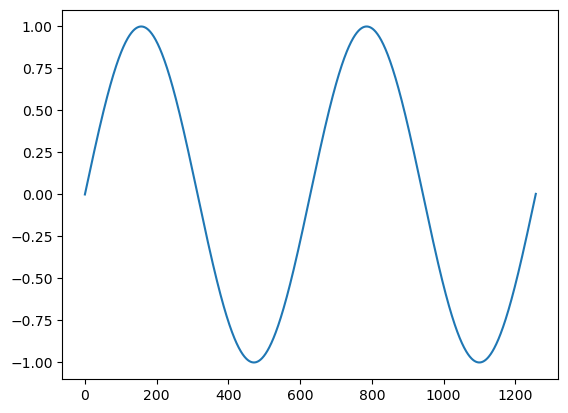

In [5]:
domain = [-2*np.pi, 2*np.pi]
f = lambda x: np.sin(x)
def plot(domain, step, f, verbose = False):
    samples = np.arange(domain[0], domain[1]+step, step)
    points = list(map(f, samples))
    if verbose:
        print(points)
    plt.plot(points)
plot(domain, 0.01, f)

In [6]:
IH_map = fd.block_learning_map(I_space, H_space, 100, (100, 100), learn_rate=0.0001, decay_rate=0.0001)
HO_map = fd.block_learning_map(H_space, O_space, 100, (100, 100), learn_rate=0.0001, decay_rate=0.0001)
percision = 0.1
out_range = [-1, 1]
def forward(x):
    global I_space, H_space, O_space, in_base, in_ssp, out_base, out_ssp, IH_map, HO_map
    in_vec = I_space.bind(in_base, I_space.ssp_phase(in_ssp, x))
    out_vec = HO_map.forwards(IH_map.forwards(in_vec))
    out_vals = list(np.arange(out_range[0], out_range[1]+percision, percision))
    best_out = max(out_vals, key=lambda x: sim(x, out_vec, out_base, out_ssp))
    return best_out
    




[np.float64(-0.20000000000000018), np.float64(-0.20000000000000018), np.float64(-0.20000000000000018), np.float64(-0.20000000000000018), np.float64(-0.20000000000000018), np.float64(-0.20000000000000018), np.float64(-0.20000000000000018), np.float64(-0.20000000000000018), np.float64(-0.30000000000000016), np.float64(-0.30000000000000016), np.float64(-0.30000000000000016), np.float64(0.6999999999999997), np.float64(0.5999999999999996), np.float64(0.6999999999999997), np.float64(0.6999999999999997), np.float64(0.6999999999999997), np.float64(0.5999999999999996), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), np.float64(-0.9), n

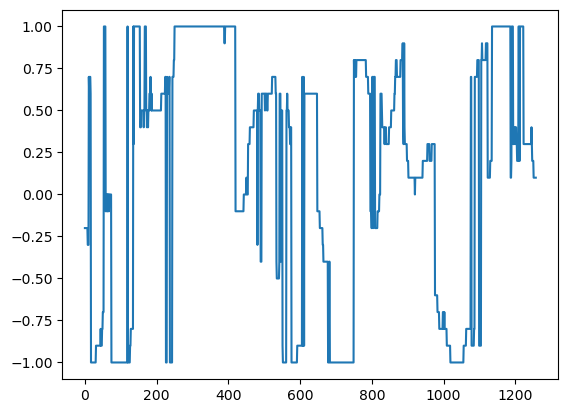

In [7]:
plot(domain, 0.01, forward, verbose=True)

In [8]:
for sample in [random.random() for _ in range(10000)]:
    x = (sample * (domain[1]-domain[0]))+domain[0]
    y = f(x)
    x_vec = I_space.bind(in_base, I_space.ssp_phase(in_ssp, x))
    y_vec = O_space.bind(out_base, O_space.ssp_phase(out_ssp, y))
    h_vec = H_space.init_random_vec()
    IH_map.learn(x_vec, h_vec)
    HO_map.learn(h_vec, y_vec)

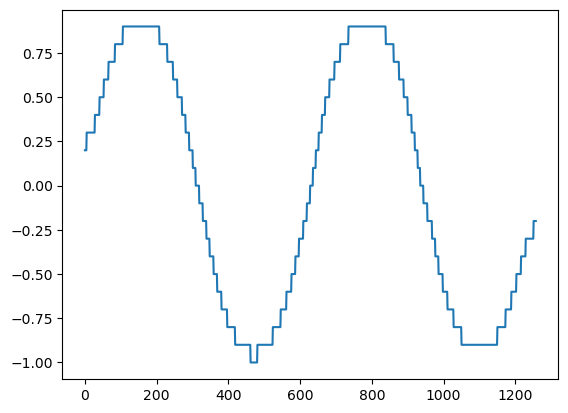

In [9]:
plot(domain, 0.01, forward)